In [20]:
!pip install kagglehub pandas matplotlib seaborn scikit-learn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [21]:
kagglehub.login()
path = kagglehub.competition_download("santander-customer-transaction-prediction")
print(path)

C:\Users\LENOVO\.cache\kagglehub\competitions\santander-customer-transaction-prediction


In [22]:
print(os.listdir(path))

['sample_submission.csv', 'test.csv', 'train.csv']


In [23]:
df = pd.read_csv(os.path.join(path, "train.csv"))

In [24]:
df.head(5)

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [25]:
df.shape

(200000, 202)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [27]:
df.isnull().sum()

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

In [34]:
df["target"].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

In [37]:
_, df_sample = train_test_split(df, test_size=40000, stratify=df['target'], random_state=42)
df_sample = df_sample.reset_index(drop=True)

In [38]:
df_sample

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_199837,0,8.7757,6.7905,9.2920,4.8443,10.8877,3.5858,4.7267,14.1264,...,4.8996,4.4960,2.0201,5.0578,18.7864,-0.2550,4.0958,7.9291,17.6055,-7.4019
1,train_149409,0,7.5491,-8.4764,15.4626,3.6803,12.1527,-7.1858,5.1952,13.7568,...,10.2822,11.9053,3.0869,-0.6879,22.3453,-2.1595,4.1147,9.2685,12.2069,1.3086
2,train_43642,0,5.8385,-6.9177,8.1589,6.7591,9.0635,4.9003,4.7126,21.1854,...,0.0732,10.2627,-0.3105,6.8481,15.2119,-0.5050,1.8873,8.6977,18.6569,11.5001
3,train_157332,0,15.6901,-7.7904,8.3676,6.3246,9.8144,6.9361,4.5284,11.7888,...,11.8331,4.3828,2.9730,2.4989,18.6336,1.0621,-3.8953,8.7950,12.9313,-3.1393
4,train_189470,0,15.5726,-6.6387,12.0251,7.2093,10.3838,-8.9961,4.8868,18.8259,...,7.9042,10.4118,3.3438,0.4358,16.0511,0.7758,-3.3334,7.7918,18.2619,-3.2074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,train_7751,0,13.9605,1.6317,16.5365,5.5922,12.2347,-14.3060,5.0389,18.4215,...,-1.3783,8.9957,2.2425,9.3388,14.8871,0.8290,-1.0208,8.3668,16.5769,2.4484
39996,train_112628,0,7.4985,4.7339,11.9952,6.2574,9.8171,4.6362,4.6372,13.3072,...,5.5200,9.0240,2.1368,4.9087,16.1938,0.5539,6.7445,10.1029,20.6326,-19.7800
39997,train_71398,0,4.5195,3.8886,7.4813,8.1466,11.8629,-4.4444,5.1001,23.0027,...,7.0380,3.5980,1.9735,3.4259,15.9605,1.0190,3.0311,6.7328,15.8304,-2.2132
39998,train_39497,0,8.8422,3.3068,8.3702,9.4941,11.5611,13.2109,5.3921,11.9120,...,7.4395,10.4932,3.7310,11.7952,17.9021,-1.4007,-6.2355,9.4922,14.9396,-9.6255


In [35]:
X = df_sample.drop(columns=['target', 'ID_code'])
y = df_sample['target']

In [39]:
X

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.7757,6.7905,9.2920,4.8443,10.8877,3.5858,4.7267,14.1264,1.9131,7.1682,...,4.8996,4.4960,2.0201,5.0578,18.7864,-0.2550,4.0958,7.9291,17.6055,-7.4019
1,7.5491,-8.4764,15.4626,3.6803,12.1527,-7.1858,5.1952,13.7568,2.5632,8.1126,...,10.2822,11.9053,3.0869,-0.6879,22.3453,-2.1595,4.1147,9.2685,12.2069,1.3086
2,5.8385,-6.9177,8.1589,6.7591,9.0635,4.9003,4.7126,21.1854,-3.5385,8.3261,...,0.0732,10.2627,-0.3105,6.8481,15.2119,-0.5050,1.8873,8.6977,18.6569,11.5001
3,15.6901,-7.7904,8.3676,6.3246,9.8144,6.9361,4.5284,11.7888,3.3775,8.8897,...,11.8331,4.3828,2.9730,2.4989,18.6336,1.0621,-3.8953,8.7950,12.9313,-3.1393
4,15.5726,-6.6387,12.0251,7.2093,10.3838,-8.9961,4.8868,18.8259,-5.2734,7.3476,...,7.9042,10.4118,3.3438,0.4358,16.0511,0.7758,-3.3334,7.7918,18.2619,-3.2074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,13.9605,1.6317,16.5365,5.5922,12.2347,-14.3060,5.0389,18.4215,4.0158,7.0972,...,-1.3783,8.9957,2.2425,9.3388,14.8871,0.8290,-1.0208,8.3668,16.5769,2.4484
39996,7.4985,4.7339,11.9952,6.2574,9.8171,4.6362,4.6372,13.3072,-0.5075,8.3850,...,5.5200,9.0240,2.1368,4.9087,16.1938,0.5539,6.7445,10.1029,20.6326,-19.7800
39997,4.5195,3.8886,7.4813,8.1466,11.8629,-4.4444,5.1001,23.0027,-3.2955,6.2351,...,7.0380,3.5980,1.9735,3.4259,15.9605,1.0190,3.0311,6.7328,15.8304,-2.2132
39998,8.8422,3.3068,8.3702,9.4941,11.5611,13.2109,5.3921,11.9120,-2.1810,5.9458,...,7.4395,10.4932,3.7310,11.7952,17.9021,-1.4007,-6.2355,9.4922,14.9396,-9.6255


In [40]:
y

0        0
1        0
2        0
3        0
4        0
        ..
39995    0
39996    0
39997    0
39998    0
39999    0
Name: target, Length: 40000, dtype: int64

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
c_values = [0.001, 0.1, 1, 100]
results = []
roc = {}

In [44]:
for c in c_values:
   
    model = LogisticRegression(C=c, penalty='l2', solver='saga', max_iter=2000, class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    
   
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc[c] = (fpr, tpr)
    
    # calculating full metrics now :
    results.append({
        "C Value": c,
        "Train Acc": accuracy_score(y_train, y_train_pred),
        "Test Acc": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob)
    })

In [46]:
result = pd.DataFrame(results)
result

,C Value,Train Acc,Test Acc,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,0.001,0.781969,0.778875,0.286525,0.281970,0.784826,0.776119,0.419792,0.413656,0.866349,0.859439
1,0.100,0.781500,0.779500,0.286087,0.282805,0.785137,0.777363,0.419366,0.414731,0.866417,0.858521
2,1.000,0.781469,0.779500,0.286054,0.282805,0.785137,0.777363,0.419331,0.414731,0.866418,0.858508
3,100.000,0.781469,0.779500,0.286054,0.282805,0.785137,0.777363,0.419331,0.414731,0.866418,0.858508


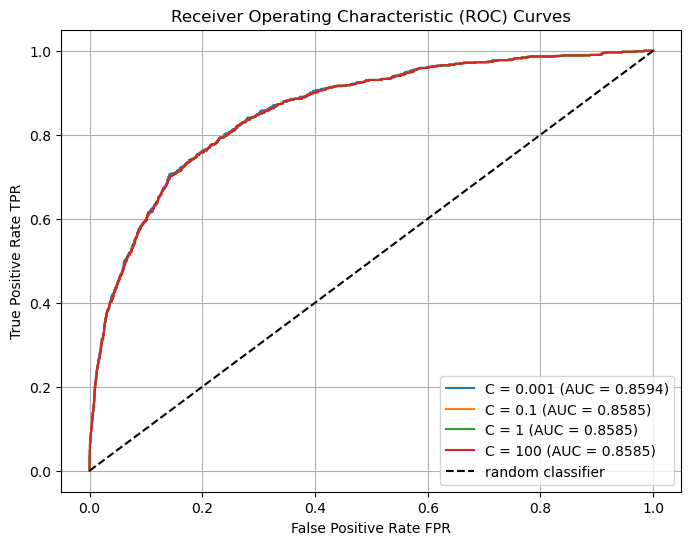

In [54]:
plt.figure(figsize=(8, 6))
for c in c_values:
    fpr, tpr = roc[c]
    test_auc = result.loc[result['C Value'] == c, 'Test AUC'].values[0]
    plt.plot(fpr, tpr, label=f'C = {c} (AUC = {test_auc:.4f})')
    
plt.plot([0, 1], [0, 1], 'k--', label='random classifier')
plt.xlabel('False Positive Rate FPR')
plt.ylabel('True Positive Rate TPR')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [57]:
best_model = LogisticRegression(C=1.0, penalty='l2', solver='saga', max_iter=2000, class_weight='balanced', random_state=42)

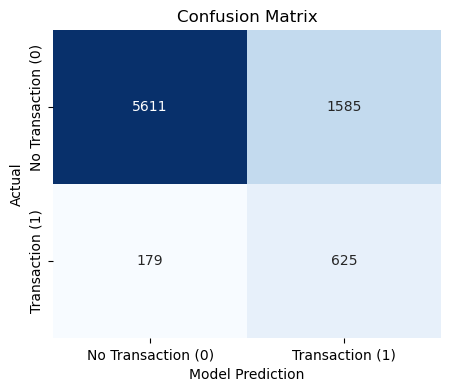

In [59]:
best_model.fit(X_train_scaled, y_train)
y_test_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_test_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Transaction (0)', 'Transaction (1)'],
            yticklabels=['No Transaction (0)', 'Transaction (1)'])

plt.ylabel('Actual')
plt.xlabel('Model Prediction')
plt.title('Confusion Matrix')
plt.show()

In [60]:
result

,C Value,Train Acc,Test Acc,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,0.001,0.781969,0.778875,0.286525,0.281970,0.784826,0.776119,0.419792,0.413656,0.866349,0.859439
1,0.100,0.781500,0.779500,0.286087,0.282805,0.785137,0.777363,0.419366,0.414731,0.866417,0.858521
2,1.000,0.781469,0.779500,0.286054,0.282805,0.785137,0.777363,0.419331,0.414731,0.866418,0.858508
3,100.000,0.781469,0.779500,0.286054,0.282805,0.785137,0.777363,0.419331,0.414731,0.866418,0.858508


Changing the regularization parameter (C) had virtually no impact on performance, making C = 0.001 the most efficient choice since it provides a strong penalty without losing any predictive power.